# Car Tracking with Noisy GPS Demo

A car drives along a figure-8 track (lemniscate). We only have noisy GPS measurements
of its position. EKF and UKF filter the noise using a constant-velocity motion model.

This notebook generates the car tracking animation shown in the README.


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from kalman.extended import ExtendedKalmanFilter
from kalman.unscented import UnscentedKalmanFilter
from kalman.gaussian import GaussianState

torch.manual_seed(7)
np.random.seed(7)


## 1. Figure-8 track and noisy GPS

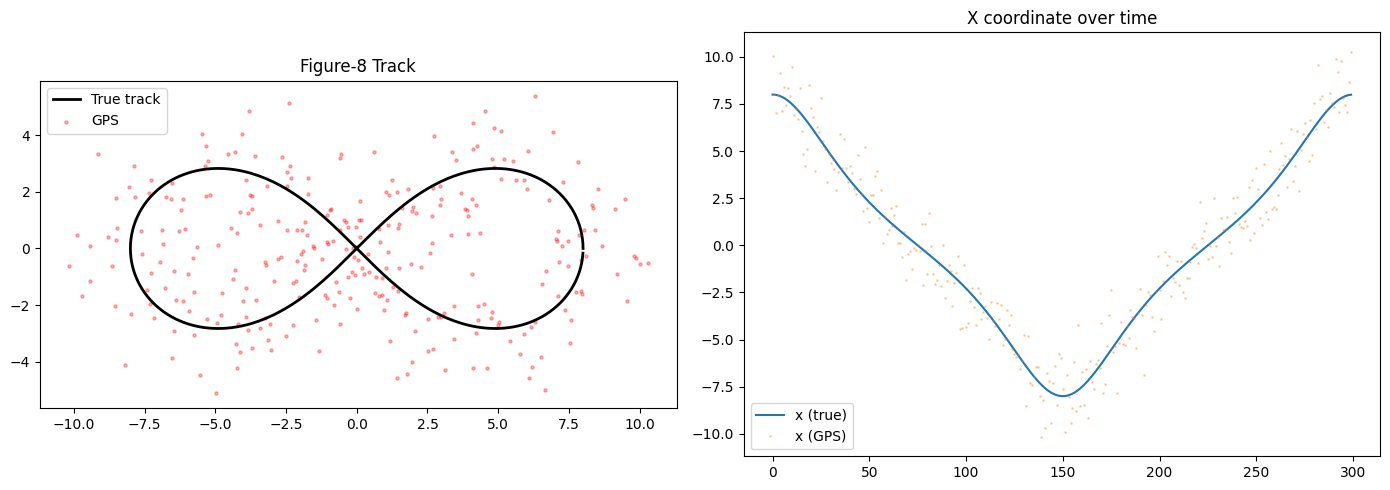

In [2]:
T = 300
dt = 0.1
t_param = np.linspace(0, 2*np.pi, T, endpoint=False)

scale = 8.0
true_x = scale * np.cos(t_param) / (1 + np.sin(t_param)**2)
true_y = scale * np.sin(t_param) * np.cos(t_param) / (1 + np.sin(t_param)**2)
true_vx = np.gradient(true_x, dt)
true_vy = np.gradient(true_y, dt)
true_states = np.stack([true_x, true_y, true_vx, true_vy], axis=-1)

gps_noise = 1.2
obs_xy = true_states[:, :2] + np.random.randn(T, 2) * gps_noise

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(true_x, true_y, 'k-', lw=2, label='True track')
axes[0].scatter(obs_xy[:,0], obs_xy[:,1], c='red', s=5, alpha=0.3, label='GPS')
axes[0].set_aspect('equal'); axes[0].legend(); axes[0].set_title('Figure-8 Track')
axes[1].plot(true_x, label='x (true)'); axes[1].plot(obs_xy[:,0], '.', ms=2, alpha=0.3, label='x (GPS)')
axes[1].legend(); axes[1].set_title('X coordinate over time')
plt.tight_layout(); plt.show()


## 2. EKF and UKF filtering

In [3]:
def f_cv(state):
    x, y, vx, vy = state[...,0], state[...,1], state[...,2], state[...,3]
    return torch.stack([x + dt*vx, y + dt*vy, vx, vy], dim=-1)

def h_gps(state):
    return state[..., :2]

def F_jac(state):
    F = torch.tensor([[1,0,dt,0],[0,1,0,dt],[0,0,1,0],[0,0,0,1]], dtype=state.dtype)
    return F.expand(*state.shape[:-1], 4, 4)

def H_jac(state):
    H = torch.tensor([[1,0,0,0],[0,1,0,0]], dtype=state.dtype)
    return H.expand(*state.shape[:-1], 2, 4)

Q = torch.diag(torch.tensor([.05, .05, .5, .5], dtype=torch.float64))
R = torch.eye(2, dtype=torch.float64) * gps_noise**2

init_mean = torch.tensor([true_x[0], true_y[0], true_vx[0], true_vy[0]], dtype=torch.float64)
init_cov = torch.diag(torch.tensor([1., 1., 5., 5.], dtype=torch.float64))
obs_t = torch.tensor(obs_xy, dtype=torch.float64)

# EKF
ekf = ExtendedKalmanFilter(4, 2, f_cv, h_gps, F_jacobian=F_jac, H_jacobian=H_jac, Q=Q, R=R, eps=1e-8)
state = GaussianState(init_mean.clone(), init_cov.clone())
ekf_m = []
for t in range(T):
    state = ekf.predict(state)
    state = ekf.update(state, obs_t[t])
    ekf_m.append(state.mean.detach().numpy())
ekf_m = np.array(ekf_m)

# UKF
ukf = UnscentedKalmanFilter(4, 2, f_cv, h_gps, alpha=1e-3, beta=2., kappa=0., Q=Q, R=R)
state = GaussianState(init_mean.clone(), init_cov.clone())
ukf_m = []
for t in range(T):
    state = ukf.predict(state)
    state = ukf.update(state, obs_t[t])
    ukf_m.append(state.mean.detach().numpy())
ukf_m = np.array(ukf_m)

ekf_rmse = np.sqrt(np.mean((ekf_m[:,:2] - true_states[:,:2])**2))
ukf_rmse = np.sqrt(np.mean((ukf_m[:,:2] - true_states[:,:2])**2))
print(f"EKF RMSE: {ekf_rmse:.3f}")
print(f"UKF RMSE: {ukf_rmse:.3f}")


EKF RMSE: 0.557
UKF RMSE: 0.557


## 3. Results

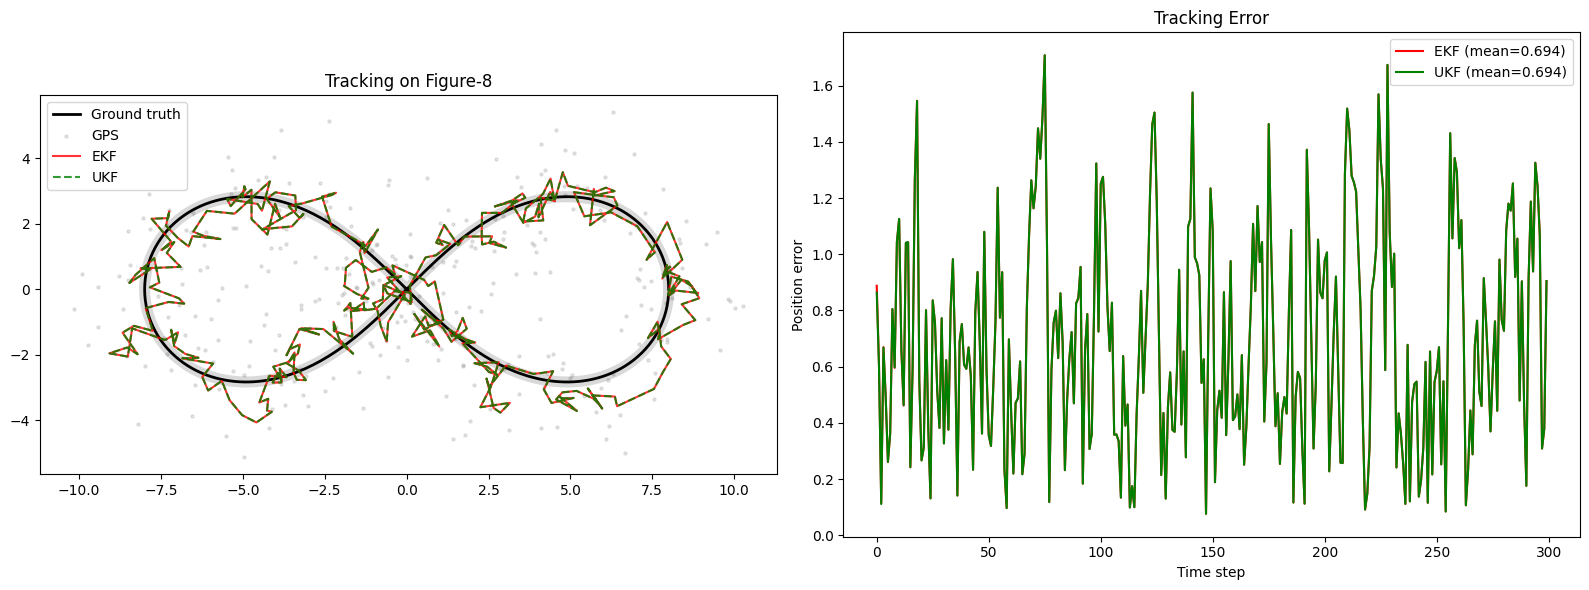

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
ax.plot(true_x, true_y, 'k-', lw=8, alpha=0.15)  # road
ax.plot(true_x, true_y, 'k-', lw=2, label='Ground truth')
ax.scatter(obs_xy[:,0], obs_xy[:,1], c='gray', s=5, alpha=0.2, label='GPS')
ax.plot(ekf_m[:,0], ekf_m[:,1], 'r-', lw=1.5, alpha=0.8, label='EKF')
ax.plot(ukf_m[:,0], ukf_m[:,1], 'g--', lw=1.5, alpha=0.8, label='UKF')
ax.set_aspect('equal'); ax.legend(); ax.set_title('Tracking on Figure-8')

ax = axes[1]
ekf_err = np.sqrt(np.sum((ekf_m[:,:2] - true_states[:,:2])**2, axis=1))
ukf_err = np.sqrt(np.sum((ukf_m[:,:2] - true_states[:,:2])**2, axis=1))
ax.plot(ekf_err, 'r-', label=f'EKF (mean={ekf_err.mean():.3f})')
ax.plot(ukf_err, 'g-', label=f'UKF (mean={ukf_err.mean():.3f})')
ax.set_xlabel('Time step'); ax.set_ylabel('Position error')
ax.set_title('Tracking Error'); ax.legend()
plt.tight_layout(); plt.show()
